In [1]:
import pandas as pd
 
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [2]:
#Clean up the columns

In [3]:
# Keep only the 2 columns we need, and rename them clearly
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
# How many total messages:
print(df.shape)

(5572, 2)


In [5]:
# How many spam vs ham?
print(df['label'].value_counts())


label
ham     4825
spam     747
Name: count, dtype: int64


In [6]:
# Any missing values?
print(df.isnull().sum())

label      0
message    0
dtype: int64


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
 
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True)
X = vectorizer.fit_transform(df['message'])
 
print(X.shape)

(5572, 8404)


In [8]:
from sklearn.model_selection import train_test_split
 
y = df['label']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
print('Training messages:', X_train.shape[0])
print('Testing messages:', X_test.shape[0])



Training messages: 4457
Testing messages: 1115


In [9]:
from sklearn.model_selection import train_test_split
 
y = df['label']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
print('Training messages:', X_train.shape[0])
print('Testing messages:', X_test.shape[0])



Training messages: 4457
Testing messages: 1115


In [10]:
# Train it
from sklearn.linear_model import LogisticRegression
 
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [11]:
from sklearn.metrics import accuracy_score
 
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)


Accuracy: 0.9443946188340807


In [12]:
sample = ["Congratulations! You have WON a free iPhone, claim now!"]
sample_vector = vectorizer.transform(sample)
prediction = model.predict(sample_vector)
print(prediction)


['spam']


In [13]:
sample2 = ["Hey, are we still meeting for lunch tomorrow?"]
sample_vector2 = vectorizer.transform(sample2)
prediction2 = model.predict(sample_vector2)
print(prediction2)

['ham']


In [14]:
#Generate your confusion matrix
from sklearn.metrics import confusion_matrix
 
cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])
print(cm)

[[962   3]
 [ 59  91]]


In [15]:
#Get the full report in one line
from sklearn.metrics import classification_report
 
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

         ham       0.94      1.00      0.97       965
        spam       0.97      0.61      0.75       150

    accuracy                           0.94      1115
   macro avg       0.96      0.80      0.86      1115
weighted avg       0.95      0.94      0.94      1115



In [16]:
#Access the vocabulary and coefficients
# Get every word the vectorizer learned, in order
feature_names = vectorizer.get_feature_names_out()
print(len(feature_names))
print(feature_names[:20])  # peek at the first 20
 
# Get the model's learned weight for each word
coefficients = model.coef_[0]
print(coefficients.shape)

8404
['00' '000' '000pes' '008704050406' '0089' '0121' '01223585236'
 '01223585334' '0125698789' '02' '0207' '02072069400' '02073162414'
 '02085076972' '021' '03' '04' '0430' '05' '050703']
(8404,)


In [17]:
# Pair up each word with its coefficient
word_weights = list(zip(feature_names, coefficients))
 
# Sort by coefficient, descending = most spam-indicating first
sorted_by_spam = sorted(word_weights, key=lambda x: x[1], reverse=True)
 
print('Top 15 words that push toward SPAM:')
for word, weight in sorted_by_spam[:15]:
    print(f'{word}: {weight:.3f}')
 
print()
print('Top 15 words that push toward HAM:')
for word, weight in sorted_by_spam[-15:]:
    print(f'{word}: {weight:.3f}')

Top 15 words that push toward SPAM:
txt: 4.477
mobile: 3.800
claim: 3.724
free: 3.607
www: 3.456
stop: 3.354
uk: 3.214
reply: 3.072
50: 2.997
service: 2.914
prize: 2.779
150p: 2.751
new: 2.750
text: 2.657
urgent: 2.415

Top 15 words that push toward HAM:
sorry: -1.103
hey: -1.107
later: -1.134
good: -1.163
way: -1.169
lor: -1.207
da: -1.276
got: -1.326
home: -1.339
going: -1.373
come: -1.447
ll: -1.600
gt: -1.685
lt: -1.695
ok: -1.870


In [18]:
print(feature_names[5000:5100])

['morphine' 'moseley' 'mother' 'motherfucker' 'motivate' 'motivating'
 'motive' 'motor' 'motorola' 'mountain' 'mountains' 'mouse' 'mouth'
 'moved' 'moves' 'movie' 'movies' 'movietrivia' 'moving' 'mp3' 'mquiz'
 'mr' 'mre' 'mrng' 'mrt' 'ms' 'msg' 'msg150p' 'msging' 'msgrcvd'
 'msgrcvd18' 'msgrcvdhg' 'msgs' 'msn' 'mt' 'mtalk' 'mth' 'mths' 'mtmsg'
 'mtmsg18' 'mtmsgrcvd18' 'mtnl' 'mu' 'muah' 'muchand' 'muchxxlove'
 'mudyadhu' 'mufti' 'muhommad' 'muht' 'multimedia' 'multiply' 'multis'
 'mum' 'mumbai' 'mumhas' 'mummy' 'mums' 'mumtaz' 'mundhe' 'munsters'
 'murali' 'murder' 'murdered' 'murderer' 'mus' 'mush' 'mushy' 'music'
 'musical' 'musicnews' 'musta' 'musthu' 'mustprovide' 'mutai' 'mutations'
 'muz' 'mw' 'mwahs' 'mylife' 'mymoby' 'myparents' 'mys' 'myspace'
 'mystery' 'n8' 'n9dx' 'na' 'naal' 'nachos' 'nag' 'nagar' 'nah' 'nahi'
 'nails' 'naked' 'nalla' 'nalli' 'name1' 'name2']


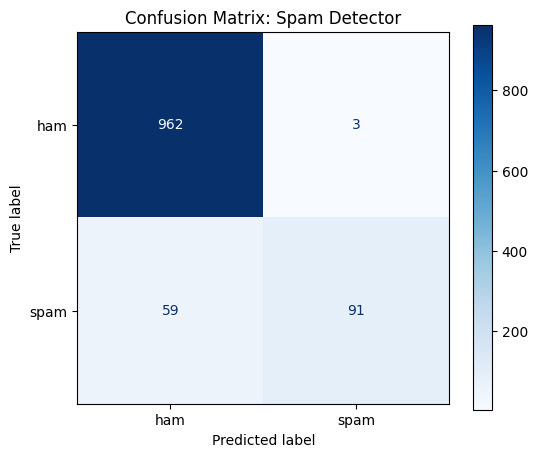

In [19]:
#heatmap
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
 
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['ham', 'spam'], cmap='Blues', ax=ax
)
plt.title('Confusion Matrix: Spam Detector')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


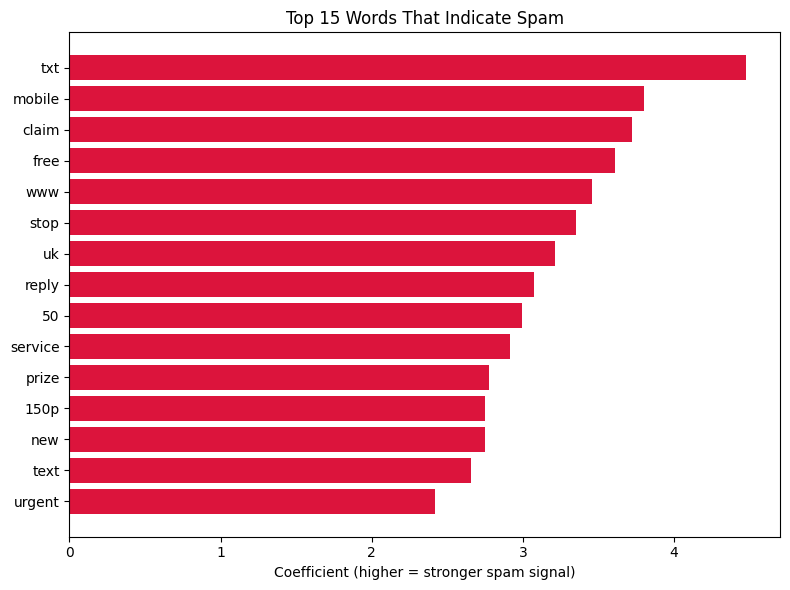

In [20]:
#Bar chart of top spam-indicating words
top_spam_words = sorted_by_spam[:15]
words = [w for w, c in top_spam_words]
weights = [c for w, c in top_spam_words]
 
plt.figure(figsize=(8, 6))
plt.barh(words[::-1], weights[::-1], color='crimson')
plt.xlabel('Coefficient (higher = stronger spam signal)')
plt.title('Top 15 Words That Indicate Spam')
plt.tight_layout()
plt.savefig('top_spam_words.png', dpi=150, bbox_inches='tight')
plt.show()


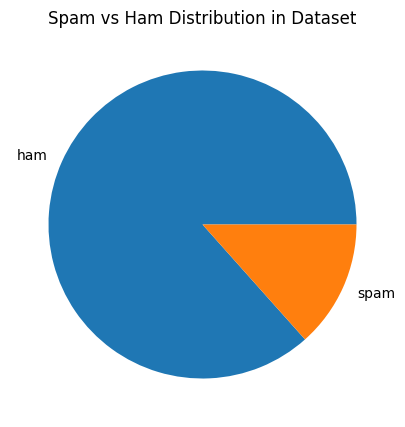

In [21]:
label_counts = df['label'].value_counts()
 
plt.figure(figsize=(5, 5))
plt.pie(label_counts, labels=label_counts.index)
plt.title('Spam vs Ham Distribution in Dataset')
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
#DAY3

In [23]:
import pickle
 
# Save the trained model
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
 
# Save the fitted vectorizer (it remembers the vocabulary + idf internally)
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
 
print('Saved model.pkl and vectorizer.pkl successfully')


Saved model.pkl and vectorizer.pkl successfully


In [24]:
print(model.classes_)


['ham' 'spam']


In [25]:
print("Intercept:", model.intercept_[0])

test_vector = vectorizer.transform(["Free iPhone congratulations, click here to proceed"])
proba = model.predict_proba(test_vector)[0]
print(f"Ham probability: {proba[0]:.3f}, Spam probability: {proba[1]:.3f}")

# Try a message closer to the dataset's actual spam style
test2 = vectorizer.transform(["WINNER! You have been selected to receive a free prize, txt CLAIM to 8007 now"])
proba2 = model.predict_proba(test2)[0]
print(f"Ham: {proba2[0]:.3f}, Spam: {proba2[1]:.3f}")

Intercept: -2.40796268382488
Ham probability: 0.705, Spam probability: 0.295
Ham: 0.027, Spam: 0.973
